In [54]:
import os, matplotlib, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
if not getattr(matplotlib, "_autosave_patched", False):
    _old_fig_savefig = matplotlib.figure.Figure.savefig
    def _savefig_prefix(self, fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_fig_savefig(self, fname, *args, **kwargs)
    matplotlib.figure.Figure.savefig = _savefig_prefix
    _old_plt_savefig = plt.savefig
    def _plt_savefig(fname, *args, **kwargs):
        if isinstance(fname, str) and not os.path.isabs(fname):
            fname = os.path.join(OUT_DIR, fname)
            os.makedirs(os.path.dirname(fname) or OUT_DIR, exist_ok=True)
        return _old_plt_savefig(fname, *args, **kwargs)
    plt.savefig = _plt_savefig
    matplotlib._autosave_patched = True


In [55]:
import numpy as np, awkward as ak, uproot, math
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [56]:
FILE = "/ceph/omunkombwe/fit__idea_o1_v03_60.root"               
TREE = "events"


In [57]:
pt_bins = np.array([
  0.5, 0.65, 0.7, 0.8, 0.9, 1.0,
  1.1, 1.25, 1.4, 1.6, 1.8, 2.0,
  2.3, 2.6, 3.0, 3.5, 4.0, 5.0
])


In [58]:
#heta_min = np.deg2rad(10.0)
#heta_max = np.deg2rad(170.0)

In [59]:
nhit_min = 4

In [60]:
CID = {
    'DCH_DigiCollection': np.uint32(3486206992),
    'VTXBDigis': np.uint32(3128296108),
    'VTXDDigis': np.uint32(3582560660),
    'SiWrBDigis': np.uint32(1902269130),
    'SiWrDDigis': np.uint32(3109826668),
}

In [61]:
def wilson_interval(k, n, z=1):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = k/n
    z2 = z*z
    denom = 1 + z2/n
    center = (p + z2/(2*n)) / denom
    half = (z/denom) * math.sqrt((p*(1-p)/n) + (z2/(4*n*n)))
    return (max(0.0, center-half), center, min(1.0, center+half))

In [62]:
with uproot.open(FILE) as f:
    t = f[TREE]
    arr = t.arrays([
        # MC truth
        "MCParticles.momentum.x","MCParticles.momentum.y","MCParticles.momentum.z",
        "MCParticles.charge","MCParticles.PDG","MCParticles.generatorStatus",
        # Fitted tracks: per-track hit ranges and the flattened hit refs (idx, collectionID)
        "Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_begin",
        "Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_end",
        "_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.index",
        "_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.collectionID",
        # Fitted track states: to compute fitted pT via omega
        "Fitted_tracks_muon/Fitted_tracks_muon.trackStates_begin",
        "Fitted_tracks_muon/Fitted_tracks_muon.trackStates_end",
        "_Fitted_tracks_muon_trackStates/_Fitted_tracks_muon_trackStates.omega",
        "_Fitted_tracks_muon_trackStates/_Fitted_tracks_muon_trackStates.location",
        # SimDigiLinks for each subdetector 
        "_DCH_DigiSimAssociationCollection_from.index",
        "_DCH_DigiSimAssociationCollection_to.index",
        "_DCHCollection_particle.index",

        "_VTXBSimDigiLinks_from/_VTXBSimDigiLinks_from.index",
        "_VTXBSimDigiLinks_to/_VTXBSimDigiLinks_to.index",
        "_VertexBarrelCollection_particle.index",

        "_VTXDSimDigiLinks_from/_VTXDSimDigiLinks_from.index",
        "_VTXDSimDigiLinks_to/_VTXDSimDigiLinks_to.index",
        "_VertexEndcapCollection_particle.index",

        "_SiWrBSimDigiLinks_from/_SiWrBSimDigiLinks_from.index",
        "_SiWrBSimDigiLinks_to/_SiWrBSimDigiLinks_to.index",
        "_SiWrBCollection_particle.index",

        "_SiWrDSimDigiLinks_from/_SiWrDSimDigiLinks_from.index",
        "_SiWrDSimDigiLinks_to/_SiWrDSimDigiLinks_to.index",
        "_SiWrDCollection_particle.index",
        "DCH_DigiSimAssociationCollection.weight",
        "VTXBSimDigiLinks.weight",  
        "VTXDSimDigiLinks.weight",  
        "SiWrBSimDigiLinks.weight",  
        "SiWrDSimDigiLinks.weight",    
    ], how=dict)

In [63]:
mc_px = arr["MCParticles.momentum.x"]
mc_py = arr["MCParticles.momentum.y"]
mc_pz = arr["MCParticles.momentum.z"]
mc_q = arr["MCParticles.charge"]
mc_pdg = arr["MCParticles.PDG"]
mc_gen = arr["MCParticles.generatorStatus"]

In [64]:
ft_beg = arr["Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_begin"]
ft_end = arr["Fitted_tracks_muon/Fitted_tracks_muon.trackerHits_end"]
ft_hit_idx = arr["_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.index"]
ft_hit_col = arr["_Fitted_tracks_muon_trackerHits/_Fitted_tracks_muon_trackerHits.collectionID"]

In [65]:
# Fitted track states (for fitted pT via omega)
ts_beg = arr["Fitted_tracks_muon/Fitted_tracks_muon.trackStates_begin"]
ts_end = arr["Fitted_tracks_muon/Fitted_tracks_muon.trackStates_end"]
ts_omega = arr["_Fitted_tracks_muon_trackStates/_Fitted_tracks_muon_trackStates.omega"]
ts_loc = arr["_Fitted_tracks_muon_trackStates/_Fitted_tracks_muon_trackStates.location"]

In [66]:

def make_digi_to_mc_map(frm, to, sim2mc, w):
    out = []
    for f_evt, t_evt, s2m_evt, w_evt in zip(frm, to, sim2mc, w):
        if len(f_evt) == 0 or len(t_evt) == 0 or len(s2m_evt) == 0:
            out.append({})
            continue
        sumw = defaultdict(lambda: defaultdict(float))   # sumw[digi][mc] += weight
        f_np, t_np, w_np = ak.to_numpy(f_evt), ak.to_numpy(t_evt), ak.to_numpy(w_evt)
        for d, s, wt in zip(f_np, t_np, w_np):
            if d is None or s is None:
                continue
            s = int(s); d = int(d)
            if s < 0 or s >= len(s2m_evt):
                continue
            mc = s2m_evt[s]
            if mc is None or mc < 0:
                continue
            wv = float(wt) if (wt is not None and np.isfinite(wt) and wt > 0) else 0.0
            sumw[d][int(mc)] += wv
        # pick MC with largest total weight per digi
        mapping = {d: max(by_mc.items(), key=lambda kv: kv[1])[0] for d, by_mc in sumw.items() if by_mc}
        out.append(mapping)
    return out


In [67]:

# Build per-subdetector digi->mc maps (per event)
dch_map = make_digi_to_mc_map(
    arr["_DCH_DigiSimAssociationCollection_from.index"],
    arr["_DCH_DigiSimAssociationCollection_to.index"],
    arr["_DCHCollection_particle.index"],
    arr["DCH_DigiSimAssociationCollection.weight"],
)
vxb_map = make_digi_to_mc_map(
    arr["_VTXBSimDigiLinks_from/_VTXBSimDigiLinks_from.index"],
    arr["_VTXBSimDigiLinks_to/_VTXBSimDigiLinks_to.index"],
    arr["_VertexBarrelCollection_particle.index"],
    arr["VTXBSimDigiLinks.weight"],
)
vxd_map = make_digi_to_mc_map(
    arr["_VTXDSimDigiLinks_from/_VTXDSimDigiLinks_from.index"],
    arr["_VTXDSimDigiLinks_to/_VTXDSimDigiLinks_to.index"],
    arr["_VertexEndcapCollection_particle.index"],
    arr["VTXDSimDigiLinks.weight"],
)
swb_map = make_digi_to_mc_map(
    arr["_SiWrBSimDigiLinks_from/_SiWrBSimDigiLinks_from.index"],
    arr["_SiWrBSimDigiLinks_to/_SiWrBSimDigiLinks_to.index"],
    arr["_SiWrBCollection_particle.index"],
    arr["SiWrBSimDigiLinks.weight"],
)
swd_map = make_digi_to_mc_map(
    arr["_SiWrDSimDigiLinks_from/_SiWrDSimDigiLinks_from.index"],
    arr["_SiWrDSimDigiLinks_to/_SiWrDSimDigiLinks_to.index"],
    arr["_SiWrDCollection_particle.index"],
    arr["SiWrDSimDigiLinks.weight"],
)

In [68]:
# Utility: given (collectionID, index) → mc particle using the appropriate map for this event

def hit_to_mc_for_event(evt, col_id, idx):
    if col_id == CID['DCH_DigiCollection']:
        return dch_map[evt].get(int(idx), None)
    if col_id == CID['VTXBDigis']:
        return vxb_map[evt].get(int(idx), None)
    if col_id == CID['VTXDDigis']:
        return vxd_map[evt].get(int(idx), None)
    if col_id == CID['SiWrBDigis']:
        return swb_map[evt].get(int(idx), None)
    if col_id == CID['SiWrDDigis']:
        return swd_map[evt].get(int(idx), None)
    # Unknown collection: skip
    return None

In [69]:
# Derived truth kinematics
mc_pt = np.sqrt(mc_px**2 + mc_py**2)
mc_p   = np.sqrt(mc_px**2 + mc_py**2 + mc_pz**2)
# theta = arccos(pz/p)
#mc_theta = np.arccos(ak.without_parameters(ak.where(mc_p>0, mc_pz/mc_p, 1.0)))

is_mu = (abs(mc_pdg) == 13)
is_final = (mc_gen == 1)  # typical for stable gun; adjust if needed
#n_acc = (mc_theta > theta_min) & (mc_theta < theta_max)
pt_cut = (mc_pt >= pt_bins[0])


In [70]:
# Storage for histogram tallies
den = np.zeros(len(pt_bins)-1, dtype=int)
num = np.zeros(len(pt_bins)-1, dtype=int)

In [71]:
n_events = len(mc_pt)

In [72]:

for evt in range(n_events):
    # 1) Build per-truth total tracker hits (over all subdetectors) using digi->mc maps
    total_hits_by_truth = Counter()
    # Count keys across all maps in this event
    for m in (dch_map[evt], vxb_map[evt], vxd_map[evt], swb_map[evt], swd_map[evt]):
        total_hits_by_truth.update(m.values())

    # 2) Track-level: figure out, for each fitted track, which mc particle contributes most hits
    #    Slice the flattened hit refs for each track using begin/end
    beg_evt = ft_beg[evt]; end_evt = ft_end[evt]
    idx_flat = ft_hit_idx[evt]; col_flat = ft_hit_col[evt]

    # Precompute per-track slices as Python ranges
    best_truth_ids = []
    purities = []
    hit_effs = []

    for b,e in zip(beg_evt, end_evt):
        if b is None or e is None or e <= b:
            best_truth_ids.append(None); purities.append(0.0); hit_effs.append(0.0); continue
        ids = idx_flat[b:e]
        cols = col_flat[b:e]
        # Count mc ids on this track
        contrib = Counter()
        valid_hit_count = 0
        for idx_val, col_val in zip(ids, cols):
            if idx_val is None or col_val is None:
                continue
            mcid = hit_to_mc_for_event(evt, np.uint32(col_val), int(idx_val))
            if mcid is None:
                continue
            contrib[mcid] += 1
            valid_hit_count += 1
        if valid_hit_count == 0 or not contrib:
            best_truth_ids.append(None); purities.append(0.0); hit_effs.append(0.0); continue
        best_mcid, shared = contrib.most_common(1)[0]
        purity = shared / float(valid_hit_count)
        total_truth_hits = total_hits_by_truth.get(best_mcid, 0)
        hit_eff = (shared / float(total_truth_hits)) if total_truth_hits > 0 else 0.0
        best_truth_ids.append(best_mcid)
        purities.append(purity)
        hit_effs.append(hit_eff)

    # 3) Mark truth muons as reconstructed if there exist atleast one a track with (purity>=0.5 & hit_eff>=0.5)
    good_match_truths = set(m for m,p,h in zip(best_truth_ids, purities, hit_effs)
                            if (m is not None and p>=0.75 and h>=0.75))

    # 4) Build reconstructable truth muon list and fill histograms
    mask_evt = (is_mu[evt]) & (is_final[evt]) 
    # & (in_acc[evt])
    pts_evt = ak.to_numpy(mc_pt[evt][mask_evt])
    # Reconstructable: ≥ nhit_min tracker hits linked to the muon
    ids_evt = np.arange(len(mask_evt), dtype=int)[ak.to_numpy(mask_evt)]
    # For each selected truth id, check hit count
    recon_ids = []
    recon_pts = []
    for tid, pt in zip(ids_evt, pts_evt):
        if total_hits_by_truth.get(int(tid), 0) >= nhit_min:
            recon_ids.append(int(tid))
            recon_pts.append(float(pt))

    if len(recon_pts) == 0:
        continue

    bins_idx = np.digitize(recon_pts, pt_bins) - 1
    for tid, b in zip(recon_ids, bins_idx):
        if 0 <= b < len(den):
            den[b] += 1
            if tid in good_match_truths:
                num[b] += 1



In [73]:
# Compute efficiencies and Wilson error bars
centers = 0.5*(pt_bins[:-1] + pt_bins[1:])
eff, elo, ehi = [], [], []
for k, n in zip(num, den):
    L, C, H = wilson_interval(k, n, z=1)
    eff.append(C)
    elo.append(C-L)
    ehi.append(H-C)

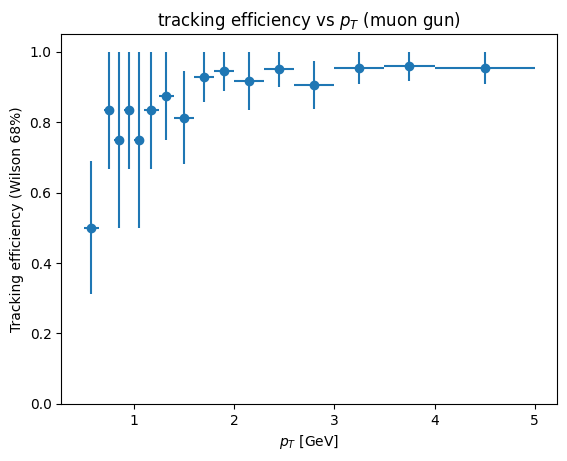

In [74]:
plt.errorbar(centers, eff, yerr=[elo, ehi], xerr=[np.diff(pt_bins)/2], fmt='o')
#plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Tracking efficiency (Wilson 68%)")
#plt.grid(True, which="both", ls=":")
plt.title("tracking efficiency vs $p_T$ (muon gun)")
plt.savefig("tracking_efficiency_vs_pT.png", dpi=150)
plt.show()

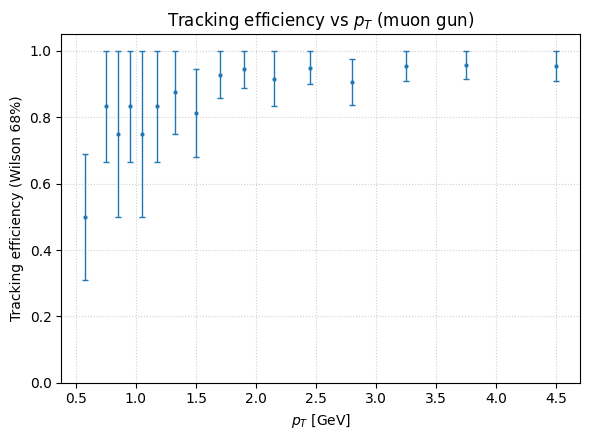

In [75]:
fig, ax = plt.subplots(figsize=(6,4.5))

ax.errorbar(
    centers, eff,
    yerr=[elo, ehi],       # asymmetric vertical errors
    fmt='o',               # points only
    linestyle='none',
    markersize=2,
    mfc='C0', mec='C0',    # filled dot
    ecolor='C0',           # bar color
    elinewidth=1,        # bar thickness
    capsize=2, capthick=1  # short horizontal caps
)

# ax.set_xscale("log")   # uncomment if you want log-x
ax.set_ylim(0, 1.05)
ax.set_xlabel(r"$p_T$ [GeV]")
ax.set_ylabel("Tracking efficiency (Wilson 68%)")
ax.grid(True, which="both", ls=":", alpha=0.6)
ax.set_title("Tracking efficiency vs $p_T$ (muon gun)")

plt.tight_layout()
plt.savefig("Tracking_efficiency_vs_pT.png", dpi=150)
plt.show()


In [76]:
import os, matplotlib.pyplot as plt
OUT_DIR = "/web/omunkombwe/public_html"
os.makedirs(OUT_DIR, exist_ok=True)
nb = "GPT_eff"
nums = plt.get_fignums()
for i, num in enumerate(nums, 1):
    fig = plt.figure(num)
    fname = f"{nb}_fig{i}.png"
    fig.savefig(fname, dpi=150)
print(f"Saved {len(nums)} figure(s) to {OUT_DIR}")


Saved 0 figure(s) to /web/omunkombwe/public_html
